# ArcGIS service REST client (`RESTesri.services`) — usage examples

Walks through every public function in `RESTesri/services.py` against live ArcGIS REST services (Image Services, Feature Services, mosaic layers):

- `getImageServiceTileUrl` — build a `{z}/{y}/{x}` tile URL template
- `queryFeatureServiceCount` — pre-flight feature count for a where/spatial filter
- `queryFeatureService` — fetch features as GeoJSON
- `getLayerInfo` — layer-level metadata (fields, geometry type, capabilities)
- `exportImage` — export a rendered image from an Image Service
- `getSupportedOperations` — list every REST operation a service actually exposes
- `computeStatisticsHistograms` — per-band pixel statistics + histogram over an area
- `identifyPixelValue` — identify the pixel value at a point
- `getSamples` — sample pixel values at multiple points
- `queryBoundary` — the true (non-rectangular) coverage boundary of an Image Service

Two live test services are used throughout:

- **Image Service** — [LCMS Annual Change (CONUS)](https://imagery.geoplatform.gov/iipp/rest/services/Vegetation/USFS_EDW_LCMS_AnnualChange_CONUS/ImageServer), a USFS mosaic dataset where each raster in the catalog is one calendar year of the Landscape Change Monitoring System's annual change classification. Filtering to a single year is done with a mosaic rule (`{"where": "year=<yyyy>"}`) rather than a URL path, since the "layers" here are catalog rows, not sub-services.
- **Cached Map Service** — Esri's public [`World_Imagery`](https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer) basemap, used only for `getImageServiceTileUrl`: it is *tile-cached*, which the LCMS Image Service is not.
- **Feature Service** — Esri's public [`Earthquakes_Since1970`](https://sampleserver6.arcgisonline.com/arcgis/rest/services/Earthquakes_Since1970/FeatureServer/0) sample service: worldwide earthquake point records with a `magnitude` field, good for both attribute and spatial (bbox) filtering.

In [1]:
import sys
from pathlib import Path

# This notebook lives in RESTesri/examples/ — add the project root (two levels up)
# to sys.path so `RESTesri` is importable.
sys.path.insert(0, str(Path.cwd().parent.parent))

from RESTesri.services import (
    getImageServiceTileUrl,
    queryFeatureServiceCount,
    queryFeatureService,
    getLayerInfo,
    exportImage,
    getSupportedOperations,
    computeStatisticsHistograms,
    identifyPixelValue,
    getSamples,
    queryBoundary,
)

In [2]:
IMG = "https://imagery.geoplatform.gov/iipp/rest/services/Vegetation/USFS_EDW_LCMS_AnnualChange_CONUS/ImageServer"
FEATURES = "https://sampleserver6.arcgisonline.com/arcgis/rest/services/Earthquakes_Since1970/FeatureServer/0"
# A tile-cached service, for the tile-URL example below. LCMS is not cached.
TILED = "https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer"

# A small AOI near the 2020 Castle Fire (Sequoia National Forest, CA) used for
# the Image Service examples below.
AOI_BBOX = "-118.65,36.05,-118.45,36.25"
YEAR_2020 = {"where": "year=2020"}  # mosaic rule: restrict LCMS to a single year

## 1. `getImageServiceTileUrl` — build a tile URL template

ArcGIS tile URLs use `{z}/{y}/{x}` order (y before x), not the XYZ standard `{z}/{x}/{y}`.

This is **pure string construction** — no request is made and nothing is validated. In particular it cannot tell whether the service is actually tiled: only *cached* services serve `/tile`. So we point it at `TILED` (a cached Map Service) rather than at the LCMS Image Service used everywhere else in this notebook, which has no tile cache at all.

In [3]:
getImageServiceTileUrl(TILED)

'https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'

Building a template against an **uncached** service silently succeeds — the string is well-formed, but every tile it points at answers HTTP 404. Check for `tileInfo` in the service's `?f=json` before relying on tiles; render an uncached Image Service with `exportImage` (section 5) instead.

In [4]:
from RESTesri._http import fetch_bytes, fetch_json

print("World_Imagery tiled?", "tileInfo" in fetch_json(TILED, {"f": "json"}))
print("LCMS tiled?        ", "tileInfo" in fetch_json(IMG, {"f": "json"}))

raw, ctype = fetch_bytes(getImageServiceTileUrl(TILED).format(z=6, y=25, x=12))
print(f"cached tile  -> {len(raw):,} bytes of {ctype}")

try:
    fetch_bytes(getImageServiceTileUrl(IMG).format(z=6, y=25, x=12))
except RuntimeError as exc:
    print("uncached tile ->", exc)

World_Imagery tiled? True
LCMS tiled?         False
cached tile  -> 17,057 bytes of image/jpeg
uncached tile -> Request failed (404): https://imagery.geoplatform.gov/iipp/rest/services/Vegetation/USFS_EDW_LCMS_AnnualChange_CONUS/ImageServer/tile/6/25/12


## 2. `queryFeatureServiceCount` — pre-flight feature count

A cheap `returnCountOnly=true` request — useful to check how big a result set would be before fetching geometry with `queryFeatureService`.

In [4]:
queryFeatureServiceCount(FEATURES)  # every earthquake record in the service

1470

In [5]:
queryFeatureServiceCount(FEATURES, where="magnitude>=7")

334

## 3. `queryFeatureService` — fetch features as GeoJSON

Runs the same count pre-flight as above, then fetches geometry + attributes as a GeoJSON `FeatureCollection`. `where` filters by attribute; `geometry`/`geometry_type` add a spatial filter (bbox string, GeoJSON geometry dict, or Esri JSON all work).

In [7]:
biggest = queryFeatureService(FEATURES, where="magnitude>=8", out_fields="name,magnitude,date_")
sorted((f["properties"] for f in biggest["features"]), key=lambda p: -p["magnitude"])[:5]

[{'name': 'INDONESIA: SUMATRA: OFF WEST COAST',
  'magnitude': 9,
  'date_': 1104019200000},
 {'name': 'INDONESIA: SUMATERA: SW', 'magnitude': 8.7, 'date_': 1111968000000},
 {'name': 'PERU: AREQUIPA, MOQUEGUA, TACNA, AYACUCHO',
  'magnitude': 8.4,
  'date_': 993254400000},
 {'name': 'INDONESIA: SUMATRA', 'magnitude': 8.4, 'date_': 1189555200000},
 {'name': 'RUSSIA: KURIL ISLANDS; JAPAN: HOKKAIDO',
  'magnitude': 8.3,
  'date_': 781228800000}]

A bbox string as the spatial filter — every California-area quake of magnitude 6+:

In [8]:
ca_quakes = queryFeatureService(
    FEATURES,
    geometry="-125,32,-114,42", geometry_type="esriGeometryEnvelope",
    where="magnitude>=6", out_fields="name,magnitude,date_",
)
print(len(ca_quakes["features"]), "California-area quakes with magnitude >= 6")
[f["properties"] for f in ca_quakes["features"]]

22 California-area quakes with magnitude >= 6


[{'name': 'CALIFORNIA: NORTH COAST', 'magnitude': 7.2, 'date_': 342489600000},
 {'name': 'CALIFORNIA: HONEYDEW, WHITETHORN, PETROLIA',
  'magnitude': 6.2,
  'date_': 682387200000},
 {'name': 'CALIFORNIA: HUMBOLDT COUNTY: FERNDALE,PETROLIA',
  'magnitude': 7.1,
  'date_': 704160000000},
 {'name': 'NEVADA: WELLS', 'magnitude': 6, 'date_': 1203552000000},
 {'name': 'CALIFORNIA: SAN FERNANDO', 'magnitude': 6.5, 'date_': 34905600000},
 {'name': 'CALIFORNIA: IMPERIAL VALLEY; MEXICO: MEXICALI',
  'magnitude': 6.9,
  'date_': 308793600000},
 {'name': 'MEXICO: NW', 'magnitude': 6.4, 'date_': 329356800000},
 {'name': 'CALIFORNIA: WESTMORLAND,CALIPATRIA',
  'magnitude': 6,
  'date_': 357091200000},
 {'name': 'CALIFORNIA: PALM SPRINGS', 'magnitude': 6, 'date_': 521164800000},
 {'name': 'CALIFORNIA: SUPERSTITION HILLS',
  'magnitude': 6.2,
  'date_': 564710400000},
 {'name': 'CALIFORNIA: BIG BEAR LAKE, BIG BEAR CITY',
  'magnitude': 6.7,
  'date_': 709689600000},
 {'name': 'CALIFORNIA: JOSHUA TREE,

`max_features` guards against accidentally pulling a huge result set — the count pre-flight catches it before any geometry is fetched:

In [9]:
try:
    queryFeatureService(FEATURES, where="magnitude>=5", max_features=50)
except ValueError as e:
    print(e)

Service layer has 1,249 matching features (max_features=50).
Increase max_features OR pass a `where` clause to filter, e.g. where="STATE_FIPS='06'".


`queryFeatureService` also works directly against an Image Service's mosaic catalog (each row = one contributing raster) — here, the single LCMS raster for 2020. Its native `/query` rejects `f=geojson` outright, so this transparently falls back to `f=json` and converts the Esri JSON to GeoJSON client-side.

In [12]:
mosaic_rows = queryFeatureService(IMG, where="year=2020", out_fields="name,year,category")
mosaic_rows["features"][0]["properties"], mosaic_rows["features"][0]["geometry"]["type"]

({'objectid': 76,
  'name': 'LCMS_CONUS_v2025-11_Change_2020',
  'year': 2020,
  'category': 1},
 'Polygon')

## 4. `getLayerInfo` — layer-level metadata

Fields, geometry type, and capabilities. Works for a FeatureServer sub-layer or an Image Service's mosaic footprint layer alike.

In [13]:
info = getLayerInfo(FEATURES)
print(info["name"], "-", info["geometryType"])
print("capabilities:", info["capabilities"])
[f["name"] for f in info["fields"]]

Earthquakes1970 - esriGeometryPoint
capabilities: ['Query']


['objectid',
 'year_',
 'mo',
 'dy',
 'hr',
 'mn',
 'sec',
 'tsu',
 'name',
 'latitude',
 'longitude',
 'focal',
 'magnitude',
 'mmi_int',
 'num_deaths',
 'hist_deaths',
 'num_injured',
 'hist_injured',
 'mill_damages',
 'hist_damage',
 'num_houses_dest',
 'hist_houses_dest',
 'num_houses_dam',
 'hist_houses_dam',
 'date_',
 'yyyymmdd',
 'yyyymmddhhmm',
 'yyyymmddhhmmss']

In [14]:
img_info = getLayerInfo(IMG)
print(img_info["name"])
[f["name"] for f in img_info["fields"]]

Vegetation/USFS_EDW_LCMS_AnnualChange_CONUS


['objectid',
 'name',
 'minps',
 'maxps',
 'lowps',
 'highps',
 'category',
 'tag',
 'groupname',
 'productname',
 'centerx',
 'centery',
 'zorder',
 'shape',
 'year',
 'start_time',
 'end_time']

## 5. `exportImage` — export a rendered image

Exports a rendered PNG for the 2020 LCMS Change raster over the AOI, using the service's built-in `Annual_Change` raster function (colormap) as the `rendering_rule` and the `year=2020` mosaic rule to pick that single year out of the catalog.

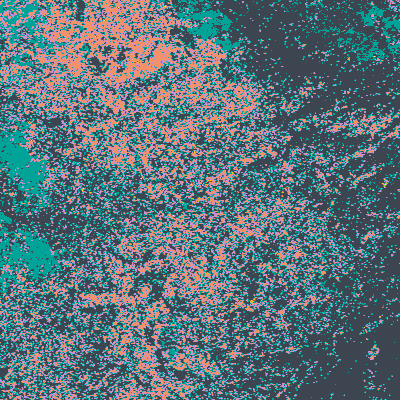

In [15]:
from IPython.display import Image

png_path = exportImage(
    IMG,
    bbox=AOI_BBOX,
    size=(400, 400),
    image_format="png",
    mosaic_rule=YEAR_2020,
    rendering_rule={"rasterFunction": "Annual_Change"},
    out_path="lcms_2020_change.png",
)
Image(png_path)

## 6. `getSupportedOperations` — every REST operation a service exposes

The `?f=json` `capabilities` string is coarse and unreliable (some operations, like `computeStatisticsHistograms` below, have no corresponding capability flag at all). This parses the authoritative list off the service's HTML browse page instead.

In [16]:
for op in getSupportedOperations(FEATURES):
    print(op["name"], "->", op["operation"])

Query -> query
Query Attachments -> queryAttachments
Calculate -> calculate
Validate SQL -> validateSQL
QueryTopFeatures -> queryTopFeatures
Generate Renderer -> generateRenderer
Return Updates -> returnUpdates
Iteminfo -> iteminfo
Thumbnail -> thumbnail
Metadata -> metadata


In [17]:
for op in getSupportedOperations(IMG):
    print(op["name"], "->", op["operation"])

Export Image -> exportImage
Query -> query
Identify -> identify
Measure -> measure
Compute Histograms -> computeHistograms
Compute Statistics Histograms -> computeStatisticsHistograms
Get Samples -> getSamples
Compute Class Statistics -> computeClassStatistics
Query GPS Info -> queryGPSInfo
Find Images -> find
Image to Map -> imageToMap
Map to Image -> mapToImage
Measure from Image -> measureFromImage
Image to Map Multiray -> imageToMapMultiray
Query Boundary -> queryBoundary
Compute Pixel Location -> computePixelLocation
Compute Angles -> computeAngles
Validate -> validate
Project -> project


## 7. `computeStatisticsHistograms` — per-band pixel statistics + histogram

Computed over the AOI at native resolution by default. LCMS Change values are class codes (this is a categorical raster), so `histogram.counts` — pixel counts per class value — is more informative here than `mean`/`stddev`.

In [18]:
stats = computeStatisticsHistograms(IMG, geometry=AOI_BBOX, geometry_type="esriGeometryEnvelope", mosaic_rule=YEAR_2020)
stats

[{'band': 0,
  'min': 4,
  'max': 15,
  'mean': 14.015867475781075,
  'stddev': 1.3665047614679517,
  'sum': 9557392.000000164,
  'median': 15,
  'mode': 15,
  'count': 681898,
  'histogram': {'min': -0.5,
   'max': 15.5,
   'size': 16,
   'counts': [0,
    0,
    0,
    0,
    17,
    10,
    0,
    741,
    2,
    81,
    0,
    0,
    202541,
    328,
    56084,
    422094]}}]

`pixel_size` computes at a coarser/finer resolution — but it's interpreted in the units of *its own* `spatialReference`, not the raster's native units. Requesting `0.001` degrees (~100 m) works fine; requesting `90` *degrees* (rather than 90 m) asks for an absurdly coarse resolution and the service silently returns nothing rather than erroring:

In [19]:
computeStatisticsHistograms(
    IMG, geometry=AOI_BBOX, geometry_type="esriGeometryEnvelope",
    mosaic_rule=YEAR_2020,
    pixel_size={"x": 0.001, "y": 0.001, "spatialReference": {"wkid": 4326}},
)

[{'band': 0,
  'min': 7,
  'max': 15,
  'mean': 14.027096774193568,
  'stddev': 1.3610023158265523,
  'sum': 695744.0000000009,
  'median': 15,
  'mode': 15,
  'count': 49600,
  'histogram': {'min': -0.5,
   'max': 15.5,
   'size': 16,
   'counts': [0, 0, 0, 0, 0, 0, 0, 50, 0, 6, 0, 0, 14590, 23, 4004, 30927]}}]

In [20]:
computeStatisticsHistograms(
    IMG, geometry=AOI_BBOX, geometry_type="esriGeometryEnvelope",
    mosaic_rule=YEAR_2020,
    pixel_size={"x": 90, "y": 90, "spatialReference": {"wkid": 4326}},  # 90 degrees, not 90 m!
)

[]

## 8. `identifyPixelValue` — identify the pixel value at a point

A single x/y only — the underlying `identify` operation silently collapses other geometry types to their centroid rather than sampling an area.

In [23]:
identifyPixelValue(IMG, x=-118.55, y=36.15, mosaic_rule=YEAR_2020)

{'value': '12',
 'band_values': ['12'],
 'location': {'x': -13196925.633542582,
  'y': 4321280.81856613,
  'spatialReference': {'wkid': 102100, 'latestWkid': 3857}},
 'catalog_items': None}

`return_catalog_items=True` also returns the footprint attributes of the raster(s) contributing at this point (e.g. which mosaic source/year):

In [24]:
r = identifyPixelValue(IMG, x=-118.55, y=36.15, mosaic_rule=YEAR_2020, return_catalog_items=True)
r["value"], r["catalog_items"][0]["attributes"]

('12',
 {'objectid': 76,
  'name': 'LCMS_CONUS_v2025-11_Change_2020',
  'minps': 0,
  'maxps': 307200,
  'lowps': 30,
  'highps': 30720,
  'category': 1,
  'tag': 'Dataset',
  'groupname': '',
  'productname': '',
  'centerx': -10746304.4748863,
  'centery': 4788208.55509629,
  'zorder': None,
  'year': 2020,
  'start_time': '20200101',
  'end_time': '20201231',
  'shape_Length': 19447365.51869365,
  'shape_Area': 22574547714030.098})

## 9. `getSamples` — sample pixel values at multiple points

One batch request for every point, with a per-point `identify` fallback (see the function's docstring) for any point the batch call can't resolve.

In [25]:
points = [(-118.55, 36.15), (-118.60, 36.10), (-118.50, 36.20)]
getSamples(IMG, points, mosaic_rule=YEAR_2020)

[{'x': -118.55, 'y': 36.15, 'value': '12', 'source': 'getSamples'},
 {'x': -118.6, 'y': 36.1, 'value': '12', 'source': 'getSamples'},
 {'x': -118.5, 'y': 36.2, 'value': '15', 'source': 'getSamples'}]

## 10. `queryBoundary` — the true coverage boundary

Unlike the rectangular `extent` from `getLayerInfo`, this is the actual coverage shape — useful as a pre-flight check for whether a service covers an AOI at all before spending an `exportImage`/`computeStatisticsHistograms` call on it.

In [26]:
boundary = queryBoundary(IMG)
print(boundary["type"], "- area:", boundary["area"])
print(len(boundary["coordinates"][0]), "vertices in the outer ring")

Polygon - area: 13499501822921.756
83 vertices in the outer ring
